In [1]:
!uv pip show scikit-learn

Name: scikit-learn
Version: 1.9.0
Location: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv\Lib\site-packages
Requires: joblib, narwhals, numpy, scipy, threadpoolctl
Required-by:


Using Python 3.12.13 environment at: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv


In [2]:
!uv pip show pandas

Name: pandas
Version: 3.0.3
Location: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv\Lib\site-packages
Requires: numpy, python-dateutil, tzdata
Required-by:


Using Python 3.12.13 environment at: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv


In [2]:
# 鸢尾花数据集 简写 iris
# 三大分类 山鸢尾 杂色鸢尾 维吉尼亚鸢尾
# 4个特征 花萼长度 花萼宽度 花瓣长度 花瓣宽度
# 安装 scikit-learn 引用 sklearn, SciPy Toolkit的缩写 SciPy工具包
# SciPy python 生态中用于科学计算的核心库

# Pandas python里的Excel + SQL, 能把杂乱的数据整理成表格，并进行各种复杂的分析和清洗

from sklearn.datasets import load_iris

iris_dataset = load_iris()
print(f"{iris_dataset.keys()}")
print(f"特征数据集合：{iris_dataset.data[0]}")
print(f"标签名称：{iris_dataset.target_names}")
print(f"所属标签：{iris_dataset.target[0]}")


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
特征数据集合：[5.1 3.5 1.4 0.2]
标签名称：['setosa' 'versicolor' 'virginica']
所属标签：0


In [3]:
import pandas as pd

df = pd.DataFrame(data=iris_dataset.data, columns=iris_dataset.feature_names)
# 再添加2列 species 种类 species_label 种类标签
df['species'] = iris_dataset.target_names[iris_dataset.target] # python 特殊写法 存的是 iris_dataset.target_names 存的是 标签名称(山鸢尾， 杂色鸢尾，维吉尼亚鸢尾 )
df.to_csv('iris_dataset_prac1.csv', index= False)

In [4]:
# 输出鸢尾花基本信息
print(f"数据集行数：{len(iris_dataset.data)}")
print(f"前10行数据：{df.head(10)}") # pandas中的DataFrame().head() 取多少数据
# 扩展 如果取几到几行的数据
print(f"统计数据:{df.describe()}")
print(f'统计各种类数量：{df['species'].value_counts().sort_values()}')

数据集行数：150
前10行数据：   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
5  setosa  
6  setosa  
7  setosa  
8  se

In [8]:
!uv pip show matplotlib

Name: matplotlib
Version: 3.10.9
Location: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv\Lib\site-packages
Requires: contourpy, cycler, fonttools, kiwisolver, numpy, packaging, pillow, pyparsing, python-dateutil
Required-by:


Using Python 3.12.13 environment at: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv


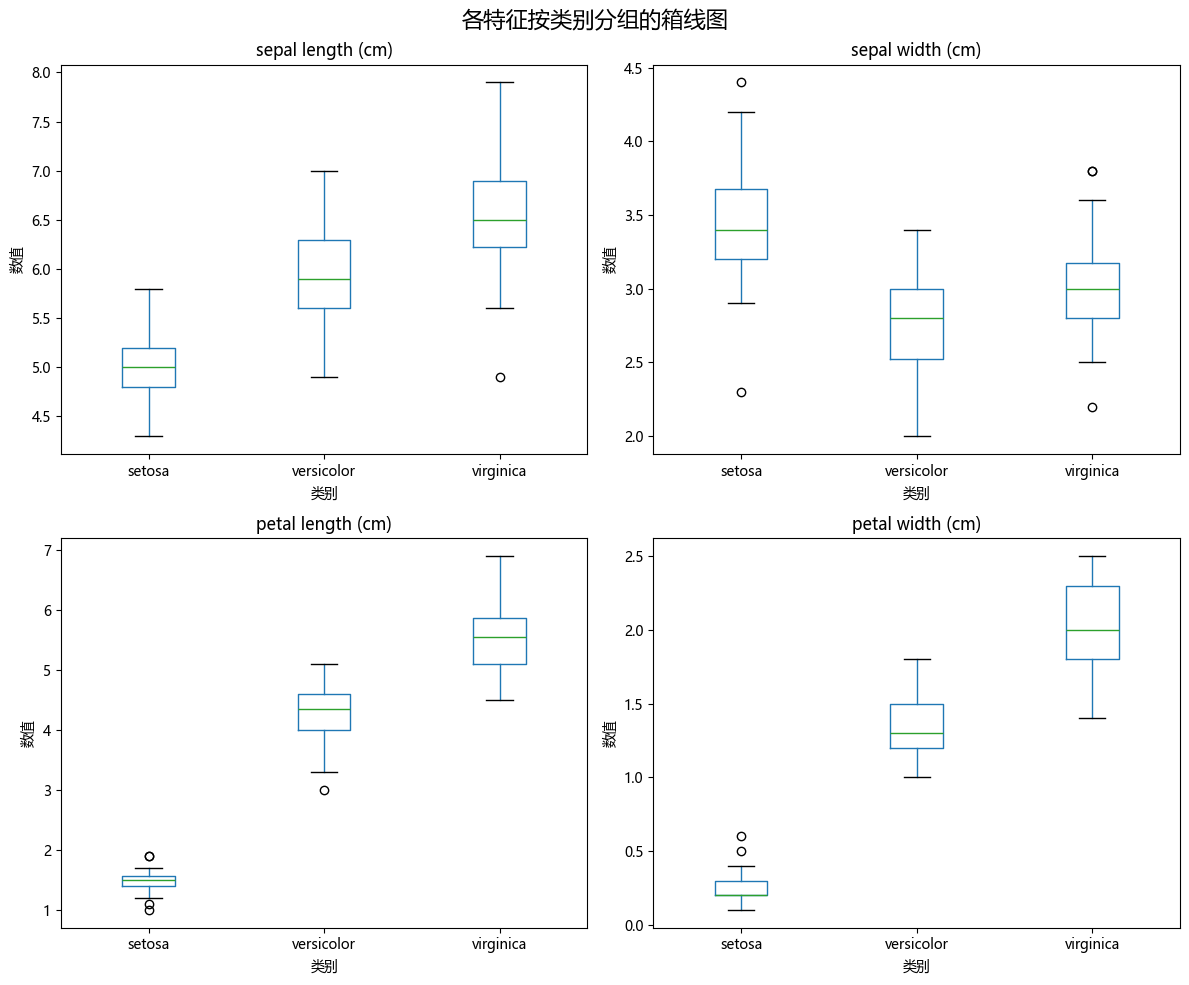

In [5]:
# 箱线图 
import matplotlib.pyplot as plt

# 设置中文
plt.rcParams['font.sans-serif'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, feature in enumerate(iris_dataset.feature_names):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    df.boxplot(column=feature, by='species', ax=ax, grid=False)
    ax.set_title(feature)
    ax.set_xlabel('类别')
    ax.set_ylabel('数值')
plt.suptitle('各特征按类别分组的箱线图', size=16)
plt.tight_layout()
plt.show()

In [6]:
# 鸢尾花数据集划分

from sklearn.model_selection import train_test_split

train_feature, test_feature, train_label, test_label = train_test_split(iris_dataset.data, iris_dataset.target, test_size=0.2, random_state=1)
print(f"训练集特征：{train_feature.shape}")
print(f"训练集标签：{train_label.shape}")
print(f"测试集特征：{test_feature.shape}")
print(f"测试集标签：{test_label.shape}")


训练集特征：(120, 4)
训练集标签：(120,)
测试集特征：(30, 4)
测试集标签：(30,)


模型：LogisticRegression，平均准确率：0.9667 (*/- 0.0408)
模型：SVC，平均准确率：0.9583 (*/- 0.0417)


C:\Users\102746\AppData\Local\Temp\ipykernel_30668\590499322.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(model_results, labels=model_names)


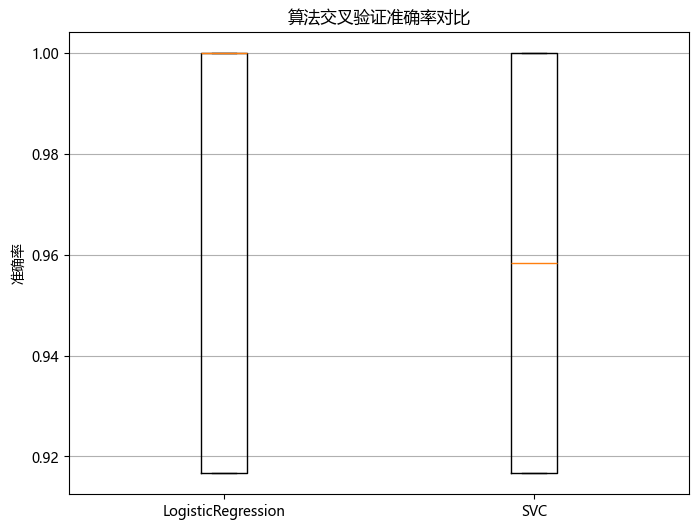

In [10]:
# 过程分三步 创建模型 -> 训练模型 -> 预测与评估

# 机器学习：从数据中学习规律，对新数据进行预测
# 监督学习：训练数据包含输入特征和已知的类别标签
# 分类任务：预测标本属于哪个离散的类型

# 机器学习领域 - 监督学习的分类算法
# 逻辑回归(LogisticRegression)：二分类(默认), 输出样本属于某一个类别的概率。举例：告诉你一朵花有95%概率是山鸢尾，5%概率是杂色鸢尾
# 支持向量机 SVM：分类（SVC）,回归（SVR）和异常检测，例如：直接判断这朵花属于 维吉尼亚鸢尾，并给出"决策边界"

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
# 引入 分层K折， 交叉验证
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

models = {
    'LogisticRegression': make_pipeline(StandardScaler(), LogisticRegression(C=1.0, solver='lbfgs', max_iter=200, random_state=1)),
    'SVC': make_pipeline(StandardScaler(), SVC(C=1.0, kernel='rbf', gamma='scale', random_state=1))
}

model_names = []
model_results = []
for name, model in models.items():
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
    scores = cross_val_score(model, train_feature, train_label, cv= skf, scoring='accuracy')
    model_results.append(scores)
    model_names.append(name)
    print(f"模型：{name}，平均准确率：{scores.mean():.4f} (*/- {scores.std():.4f})")

plt.figure(figsize=(8, 6))
plt.boxplot(model_results, labels=model_names)
plt.title('算法交叉验证准确率对比')
plt.ylabel('准确率')
plt.grid(axis='y')
plt.show()

In [11]:
svm = SVC(gamma='auto')
svm.fit(train_feature, train_label)
svm_pred = svm.predict(test_feature);

In [13]:
# 自己密切
from sklearn.metrics import accuracy_score # 计算分类准确率

acc = accuracy_score(test_label, svm_pred)
print(f"SVM在测试集上的准确率：{acc:.4f}")


SVM在测试集上的准确率：0.9667


In [14]:
!uv pip show seaborn

Using Python 3.12.13 environment at: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv


In [15]:
!uv pip install seaborn

Using Python 3.12.13 environment at: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv
Resolved 14 packages in 1.01s
Prepared 1 package in 281ms
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 1 package in 346ms
 + seaborn==0.13.2


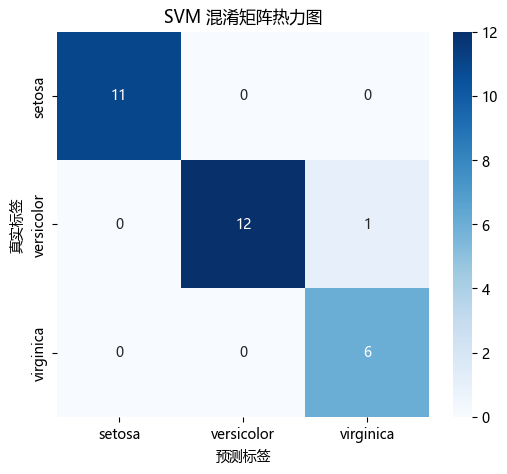

In [16]:
# 计算预测准确率并打印
#  
#
#

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_label, svm_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris_dataset.target_names, yticklabels=iris_dataset.target_names)
plt.title('SVM 混淆矩阵热力图')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.show()

(150, 2)
(150,)


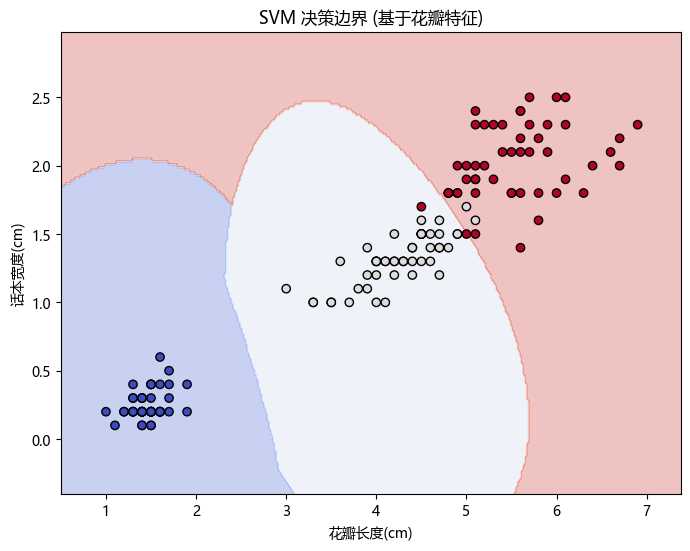

In [18]:
import numpy as np

# 决策边界图 (使用花瓣长度和花瓣宽度两个特征)
iris_dataset_data_2d = iris_dataset.data[:, 2:4]
iris_dataset_target_2d = iris_dataset.target
print(iris_dataset_data_2d.shape)
print(iris_dataset_target_2d.shape)
train_feature_2d, test_feature_2d, train_label_2d, test_label_2d = train_test_split(iris_dataset_data_2d, iris_dataset_target_2d, test_size=0.2, random_state=1)
svm_2d = SVC(gamma='auto')
svm_2d.fit(train_feature_2d, train_label_2d)

# 生成网格点
h = 0.02
x_min, x_max = iris_dataset_data_2d[:, 0].min() - 0.5, iris_dataset_data_2d[:, 0].max() + 0.5
y_min, y_max = iris_dataset_data_2d[:, 1].min() - 0.5, iris_dataset_data_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(iris_dataset_data_2d[:, 0], iris_dataset_data_2d[:, 1], c=iris_dataset_target_2d, edgecolors='k', cmap=plt.cm.coolwarm)
plt.xlabel('花瓣长度(cm)')
plt.ylabel('话本宽度(cm)')
plt.title('SVM 决策边界 (基于花瓣特征)')
plt.show()